# Comprensiónn y Análisis Exploratorio de Datos (EDA)

**Objetivo:** Realizar un anÃ¡lisis exploratorio completo de la base de datos de crÃ©ditos para comprender las caracterÃ­sticas, identificar patrones, detectar anomalÃ­as y generar reglas de validaciÃ³n.

**Variable objetivo:** `Pago_atiempo` (1 = Paga a tiempo, 0 = No paga a tiempo)

**Contenido:**
1. Exploración inicial de datos
2. Limpieza y preparación de tipos de datos
3. AnÃ¡lisis univariable
4. AnÃ¡lisis bivariable
5. AnÃ¡lisis multivariable
6. Reglas de validación
7. Transformaciones sugeridas

## 1. Importar librerí­as y cargar datos

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

In [25]:
df = pd.read_csv("../Base_de_datos.csv")
print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset cargado: 10763 filas x 23 columnas


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,12/21/24 11:31,3692160,10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,51258.00,51258.00,0.00,5,0,0,908526.00,Estable,1
1,4,4/22/25 9:47,840000,6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,8673.00,8673.00,0.00,0,0,2,939017.00,Creciente,1
2,9,1/8/26 12:22,5974028,10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,18702.00,18702.00,0.00,3,0,0,NaN,NaN,0
3,4,8/4/25 12:04,1671240,6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,15782.00,15782.00,0.00,3,0,0,1536193.00,Creciente,1
4,9,4/26/25 11:24,2781636,11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,204804.00,204804.00,0.00,3,0,1,933473.00,Creciente,1


---
## 2. Exploración inicial de datos

### 2.1 Descripción general de los datos

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  object 
 2   capital_prestado               10763 non-null  int64  
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  object 
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null 

### 2.2 Caracterización de variables

In [27]:
print("\nCaracterización de las variables del dataset\n")

print("1) Variables categóricas")

print("\nNominales:")
print("- tipo_laboral: indica si el cliente es Empleado o Independiente")
print("- tendencia_ingresos: indica la tendencia de los ingresos (Estable o Creciente)")
print("- tipo_credito: tipo de crédito (variable categórica codificada numéricamente, sin orden inherente)")

print("\n2) Variables numéricas")

print("\nVariables continuas:")
print("- capital_prestado")
print("- salario_cliente")
print("- total_otros_prestamos")
print("- cuota_pactada")
print("- puntaje y puntaje_datacredito")
print("- saldo_mora, saldo_total, saldo_principal, saldo_mora_codeudor")

print("\nVariables discretas:")
print("- plazo_meses (duración del crédito en meses)")
print("- edad_cliente")
print("- cant_creditosvigentes")
print("- huella_consulta")
print("- creditos_sectorFinanciero")
print("- creditos_sectorCooperativo")
print("- creditos_sectorReal")

print("\n3) Variable temporal")
print("- fecha_prestamo: fecha y hora en que se otorgó el crédito")

print("\n4) Variable objetivo")
print("- Pago_atiempo: variable binaria (0 = no paga a tiempo, 1 = paga a tiempo)")


Caracterización de las variables del dataset

1) Variables categóricas

Nominales:
- tipo_laboral: indica si el cliente es Empleado o Independiente
- tendencia_ingresos: indica la tendencia de los ingresos (Estable o Creciente)
- tipo_credito: tipo de crédito (variable categórica codificada numéricamente, sin orden inherente)

2) Variables numéricas

Variables continuas:
- capital_prestado
- salario_cliente
- total_otros_prestamos
- cuota_pactada
- puntaje y puntaje_datacredito
- saldo_mora, saldo_total, saldo_principal, saldo_mora_codeudor

Variables discretas:
- plazo_meses (duración del crédito en meses)
- edad_cliente
- cant_creditosvigentes
- huella_consulta
- creditos_sectorFinanciero
- creditos_sectorCooperativo
- creditos_sectorReal

3) Variable temporal
- fecha_prestamo: fecha y hora en que se otorgó el crédito

4) Variable objetivo
- Pago_atiempo: variable binaria (0 = no paga a tiempo, 1 = paga a tiempo)


### 2.3 Revisión de nulos

In [28]:
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": nulos_pct, "Tipo": df.dtypes})
resumen_nulos = resumen_nulos.sort_values("Nulos", ascending=False)
print("Resumen de valores nulos por columna:")
resumen_nulos

Resumen de valores nulos por columna:


,Nulos,Porcentaje (%),Tipo
tendencia_ingresos,2932,27.24,object
promedio_ingresos_datacredito,2930,27.22,float64
saldo_mora_codeudor,590,5.48,float64
saldo_principal,405,3.76,float64
saldo_mora,156,1.45,float64
saldo_total,156,1.45,float64
puntaje_datacredito,6,0.06,float64
salario_cliente,0,0.00,int64
tipo_laboral,0,0.00,object
edad_cliente,0,0.00,int64


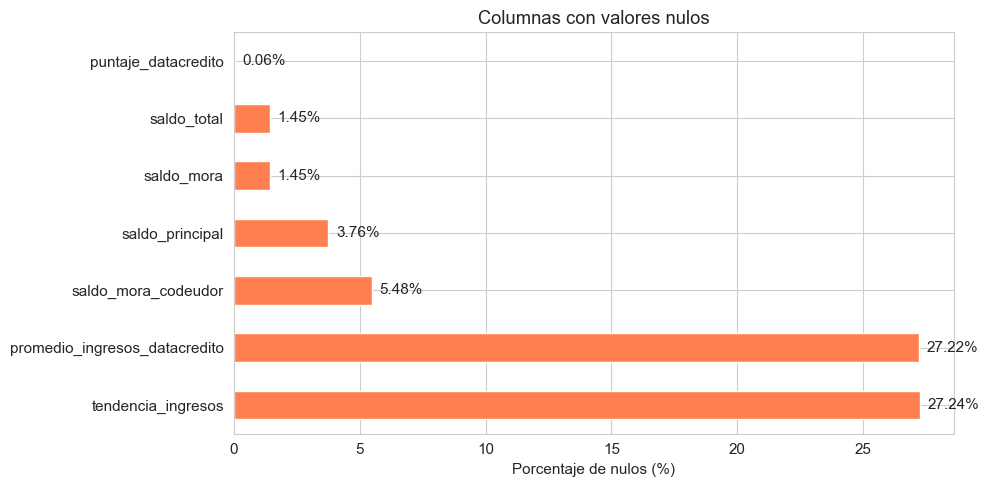

In [29]:

cols_con_nulos = resumen_nulos[resumen_nulos["Nulos"] > 0].index.tolist()
if cols_con_nulos:
    fig, ax = plt.subplots(figsize=(10, 5))
    nulos_plot = resumen_nulos.loc[cols_con_nulos, "Porcentaje (%)"]
    nulos_plot.plot(kind="barh", color="coral", ax=ax)
    ax.set_xlabel("Porcentaje de nulos (%)")
    ax.set_title("Columnas con valores nulos")
    for i, v in enumerate(nulos_plot):
        ax.text(v + 0.3, i, f"{v}%", va="center")
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron valores nulos.")

No existen columnas a eliminar

### 2.6 Conversión de tipos de datos

In [30]:
# 1. fecha_prestamo -> datetime
df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"], errors="coerce")

# 2. tipo_credito -> category
df["tipo_credito"] = df["tipo_credito"].astype("category")

# 3. tipo_laboral -> category
df["tipo_laboral"] = df["tipo_laboral"].astype("category")

# 4. tendencia_ingresos -> category
df["tendencia_ingresos"] = df["tendencia_ingresos"].astype("category")

# 5. Variables numéricas discretas -> int
cols_discretas = [
    "plazo_meses", "edad_cliente", "cant_creditosvigentes", "huella_consulta",
    "creditos_sectorFinanciero", "creditos_sectorCooperativo", "creditos_sectorReal"
]

for col in cols_discretas:
    if df[col].isnull().sum() == 0:
        df[col] = df[col].astype("int64")

print("Tipos de datos finales")
print(df.dtypes)

C:\Users\Daniel\AppData\Local\Temp\ipykernel_23052\2510894011.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"], errors="coerce")


Tipos de datos finales
tipo_credito                           category
fecha_prestamo                   datetime64[ns]
capital_prestado                          int64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                           category
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingresos

---
## 3. Análisis Univariable

### 3.1 Resumen estadístico general

In [31]:

df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
tipo_credito,10763.00,6.00,4.00,7747.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_prestamo,10763,NaN,NaN,NaN,2025-04-16 23:05:32.851435520,2024-11-26 09:17:00,2025-01-20 17:32:30,2025-03-27 16:23:00,2025-06-16 13:27:30,2026-04-26 18:43:00,NaN
capital_prestado,10763.00,NaN,NaN,NaN,2434315.00,360000.00,1224831.00,1921920.00,3084840.00,41444153.00,1909642.76
plazo_meses,10763.00,NaN,NaN,NaN,10.58,2.00,6.00,10.00,12.00,90.00,6.63
edad_cliente,10763.00,NaN,NaN,NaN,43.95,19.00,33.00,42.00,53.00,123.00,15.06
tipo_laboral,10763,2,Empleado,6754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salario_cliente,10763.00,NaN,NaN,NaN,17216431.46,0.00,2000000.00,3000000.00,4875808.00,22000000000.00,355476717.60
total_otros_prestamos,10763.00,NaN,NaN,NaN,6238869.65,0.00,500000.00,1000000.00,2000000.00,6787675263.00,118418316.94
cuota_pactada,10763.00,NaN,NaN,NaN,243617.41,23944.00,121041.50,182863.00,287833.50,3816752.00,210493.69
puntaje,10763.00,NaN,NaN,NaN,91.17,-38.01,95.23,95.23,95.23,95.23,16.47


### 3.2  variables numéricas

In [32]:
cols_numericas = ["capital_prestado", "salario_cliente", "total_otros_prestamos",
                  "cuota_pactada", "puntaje", "puntaje_datacredito",
                  "saldo_mora", "saldo_total", "saldo_principal", "saldo_mora_codeudor",
                  "promedio_ingresos_datacredito"]

### 3.3 Histogramas y distribución de variables 

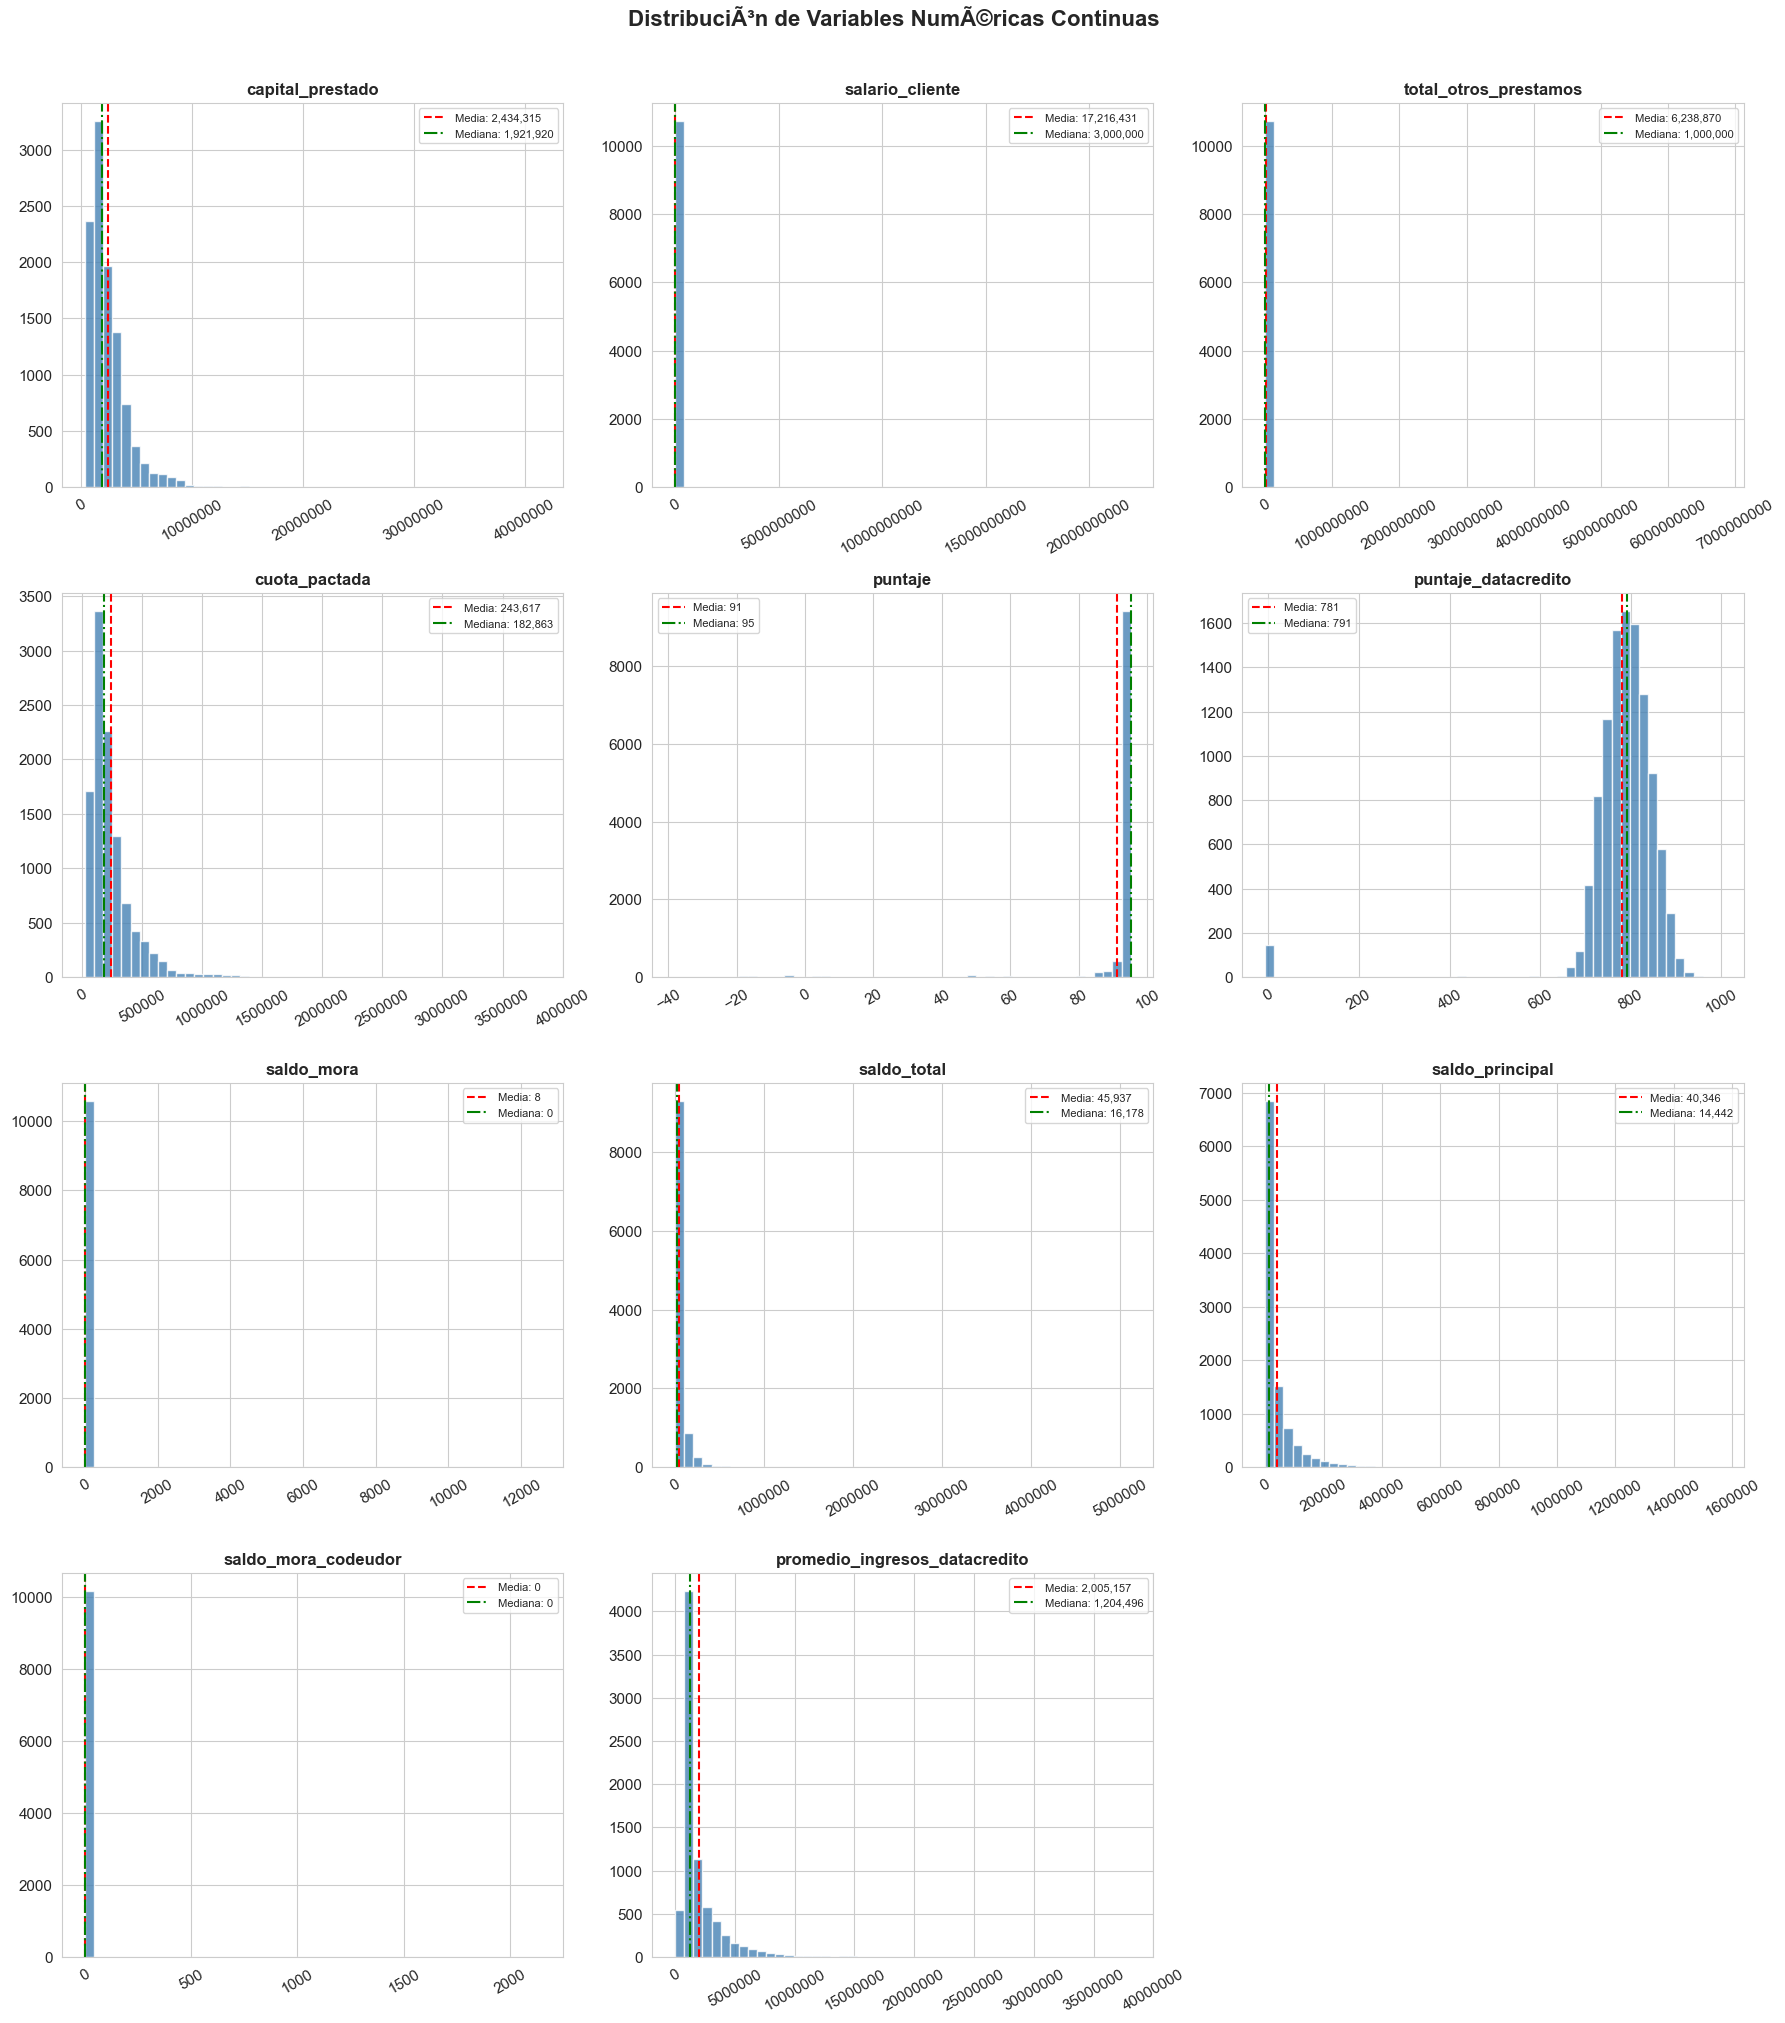

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"Media: {data.mean():,.0f}")
    ax.axvline(data.median(), color="green", linestyle="-.", label=f"Mediana: {data.median():,.0f}")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8)
    ax.ticklabel_format(style="plain", axis="x")
    ax.tick_params(axis="x", rotation=30)

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de Variables Numéricas Continuas", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Boxplots para detección de outliers

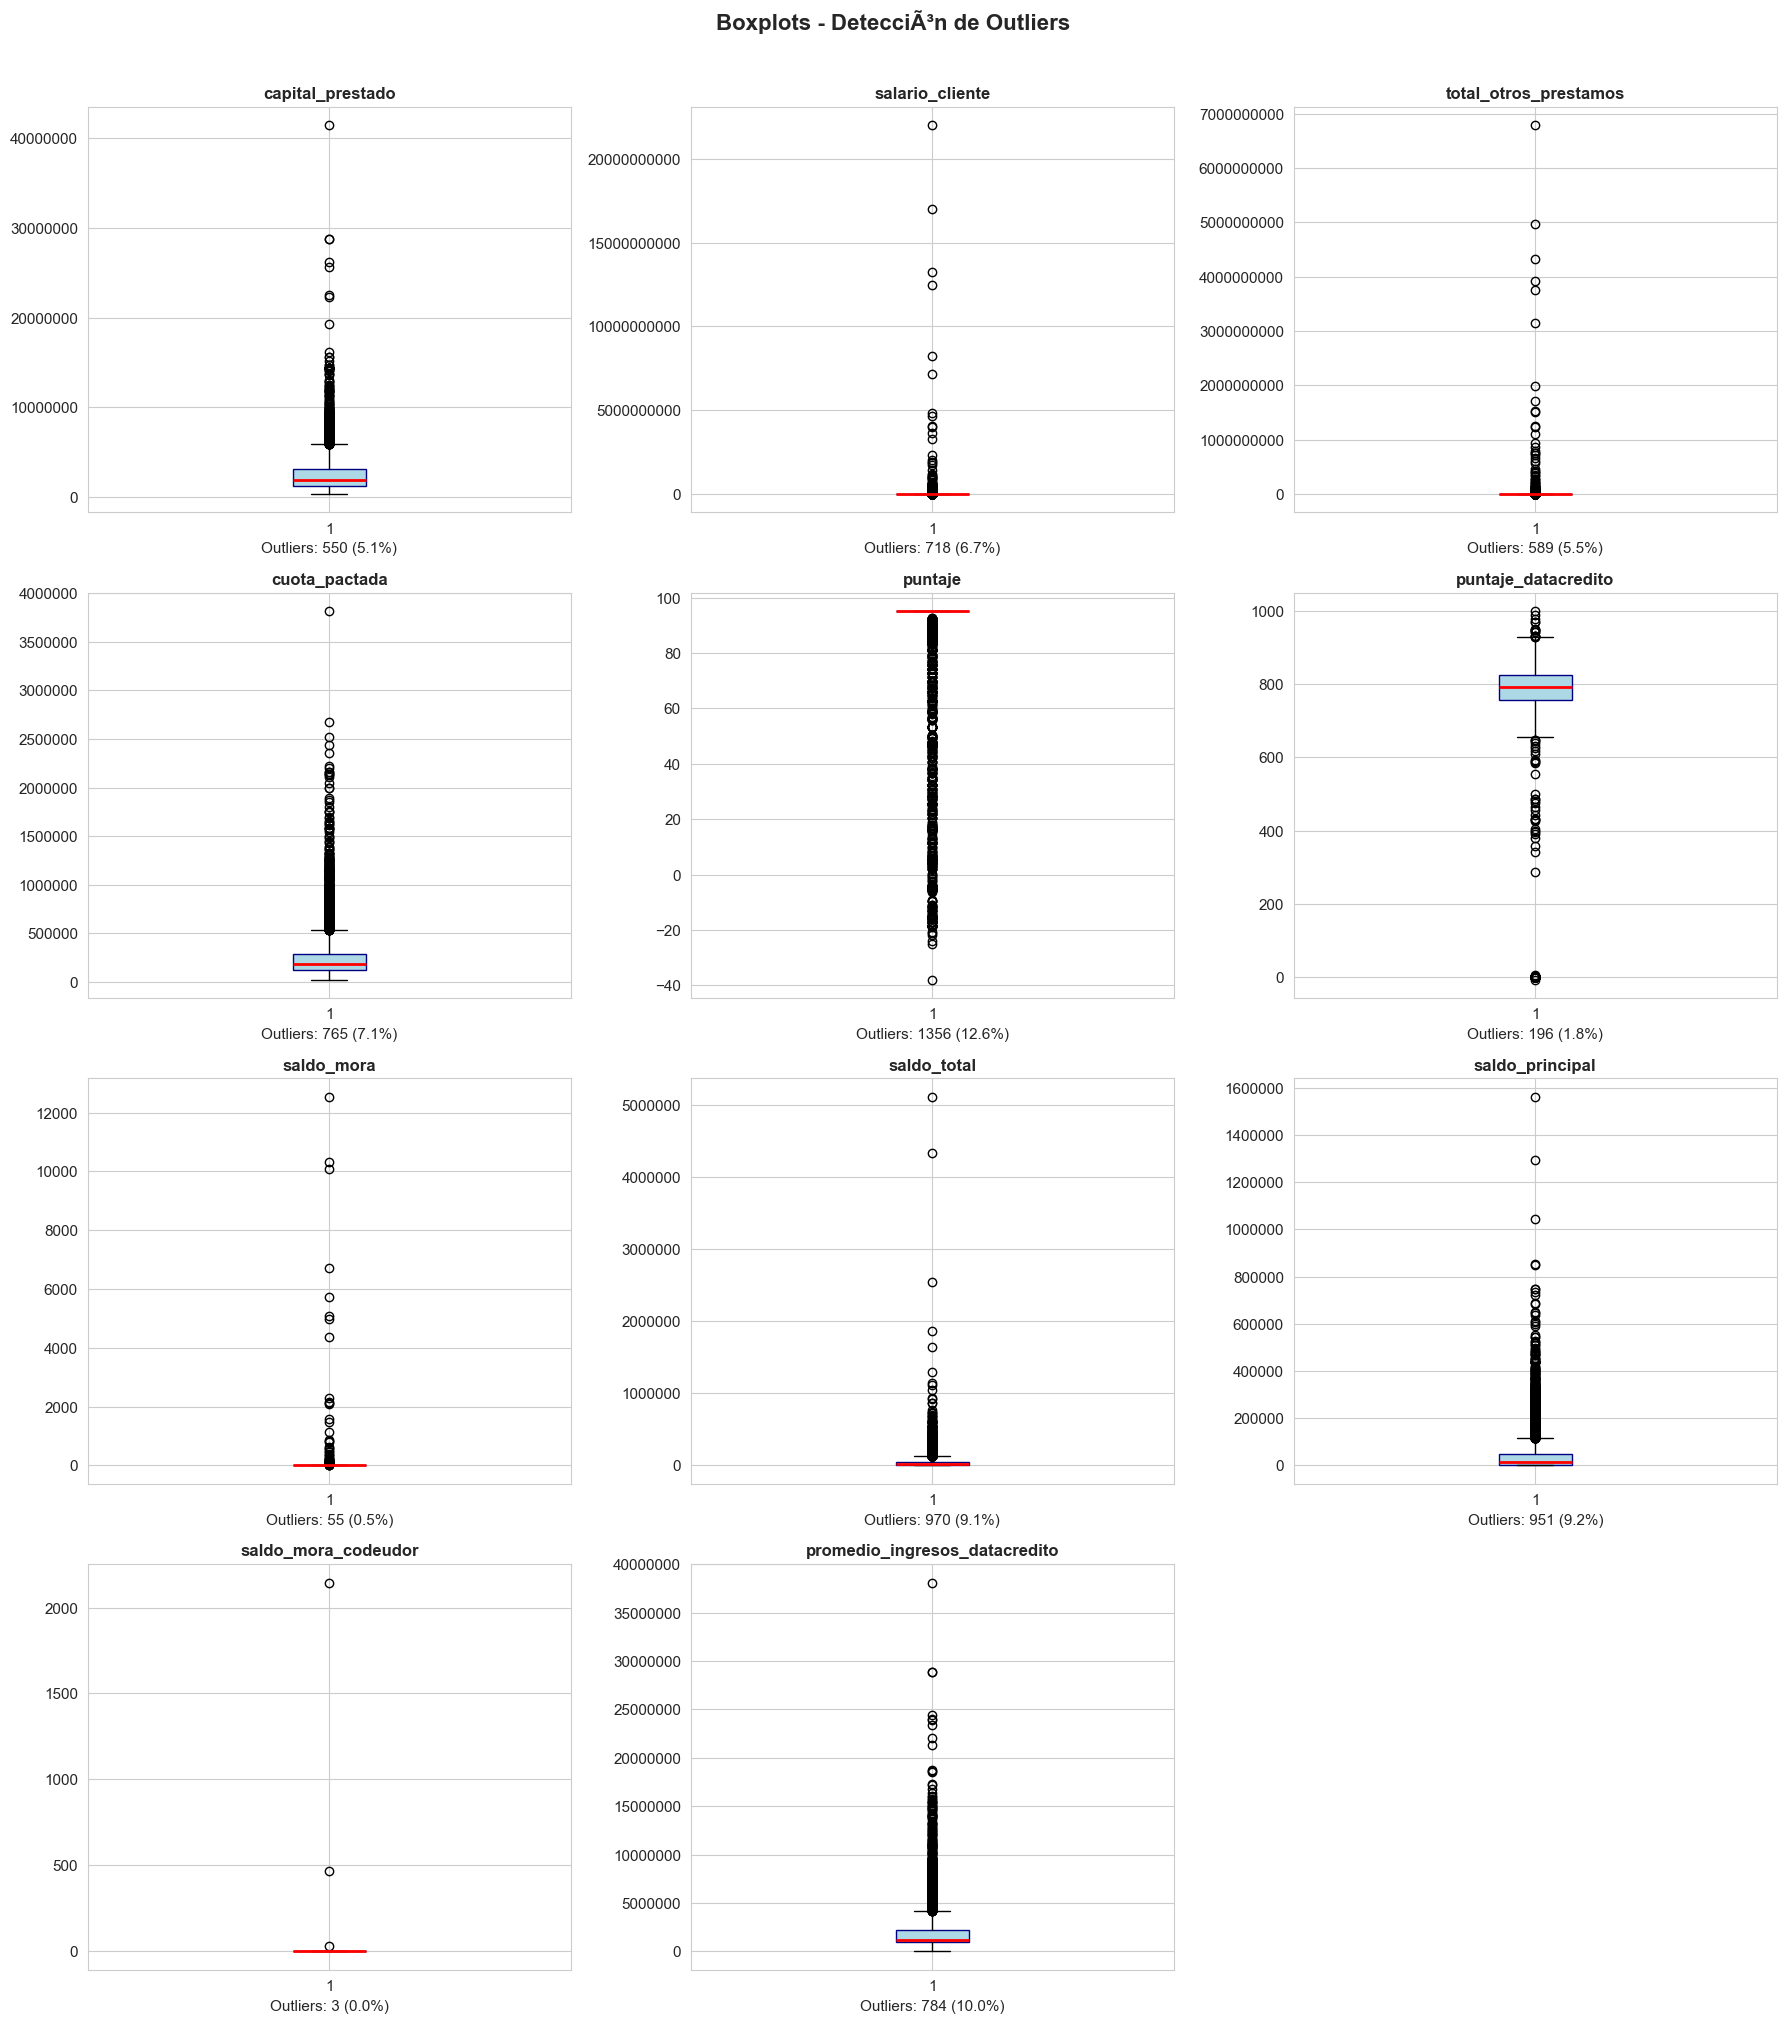

In [33]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    data = df[col].dropna()
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="lightblue", color="navy"),
                    medianprops=dict(color="red", linewidth=2))
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.ticklabel_format(style="plain", axis="y")
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    ax.set_xlabel(f"Outliers: {n_outliers} ({n_outliers/len(data)*100:.1f}%)")

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots - DetecciÃ³n de Outliers", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Variables numéricas discretas

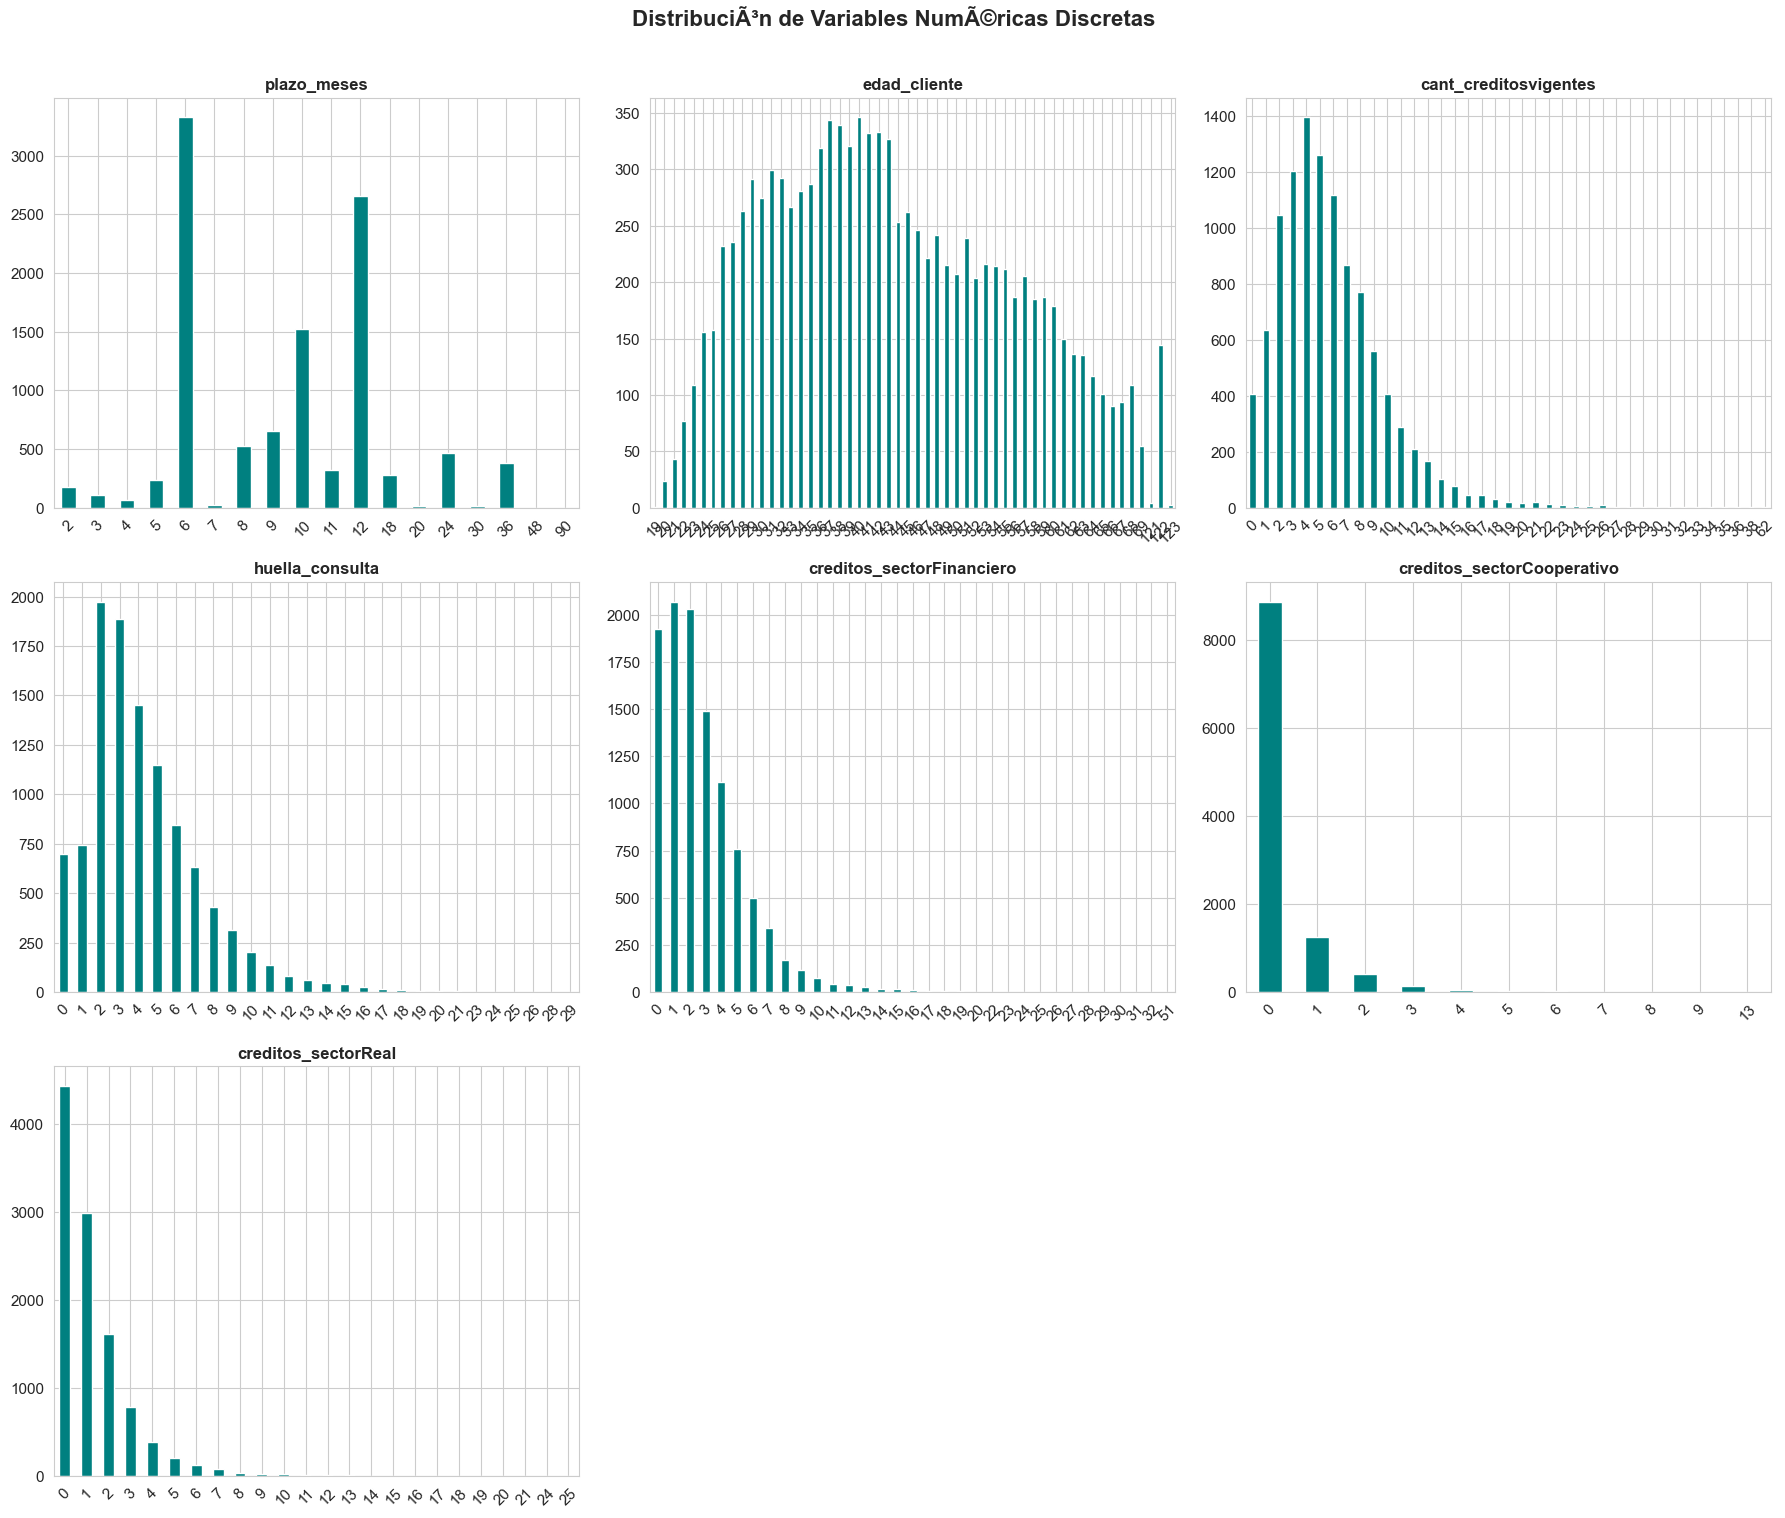

In [34]:
cols_discretas = ["plazo_meses", "edad_cliente", "cant_creditosvigentes", "huella_consulta",
                  "creditos_sectorFinanciero", "creditos_sectorCooperativo", "creditos_sectorReal"]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(cols_discretas):
    ax = axes[i]
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="teal", edgecolor="white")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

for j in range(len(cols_discretas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("DistribuciÃ³n de Variables NumÃ©ricas Discretas", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.6 Variables categóricas

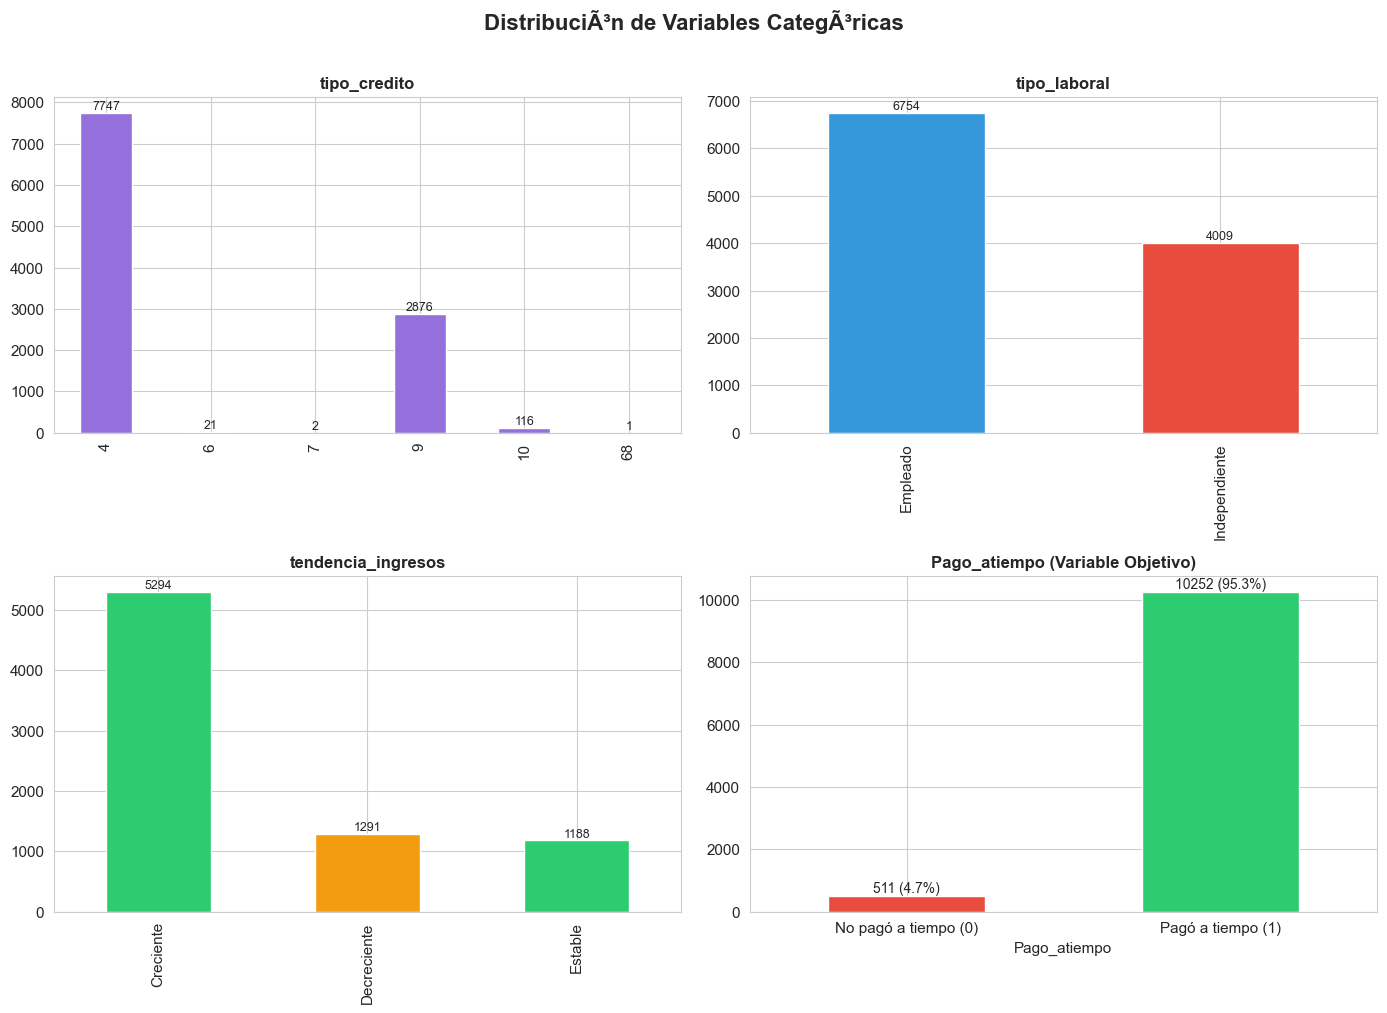

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# tipo_credito
ax = axes[0, 0]
df["tipo_credito"].value_counts().sort_index().plot(kind="bar", ax=ax, color="mediumpurple", edgecolor="white")
ax.set_title("tipo_credito", fontsize=12, fontweight="bold")
ax.set_xlabel("")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2., p.get_height()),
               ha="center", va="bottom", fontsize=9)

# tipo_laboral
ax = axes[0, 1]
df["tipo_laboral"].value_counts().plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"], edgecolor="white")
ax.set_title("tipo_laboral", fontsize=12, fontweight="bold")
ax.set_xlabel("")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2., p.get_height()),
               ha="center", va="bottom", fontsize=9)

# tendencia_ingresos
validas = ["Creciente", "Decreciente", "Estable"]

df["tendencia_ingresos"] = df["tendencia_ingresos"].where(
    df["tendencia_ingresos"].isin(validas)
)
df["tendencia_ingresos"].value_counts(dropna=False)
df["tendencia_ingresos"] = df["tendencia_ingresos"].astype("category")
df["tendencia_ingresos"] = df["tendencia_ingresos"].cat.remove_unused_categories()
ax = axes[1, 0]
df["tendencia_ingresos"].value_counts().plot(kind="bar", ax=ax, color=["#2ecc71", "#f39c12"], edgecolor="white")
ax.set_title("tendencia_ingresos", fontsize=12, fontweight="bold")
ax.set_xlabel("")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2., p.get_height()),
               ha="center", va="bottom", fontsize=9)

# Pago_atiempo (variable objetivo)
ax = axes[1, 1]
colores_target = ["#e74c3c", "#2ecc71"]
df["Pago_atiempo"].value_counts().sort_index().plot(kind="bar", ax=ax, color=colores_target, edgecolor="white")
ax.set_title("Pago_atiempo (Variable Objetivo)", fontsize=12, fontweight="bold")
ax.set_xticklabels(["No pagó a tiempo (0)", "Pagó a tiempo (1)"], rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} ({int(p.get_height())/len(df)*100:.1f}%)",
               (p.get_x() + p.get_width()/2., p.get_height()),
               ha="center", va="bottom", fontsize=10)

plt.suptitle("DistribuciÃ³n de Variables CategÃ³ricas", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [37]:
# Tablas de frecuencia detalladas
print("TABLAS DE FRECUENCIA")


for col in ["tipo_credito", "tipo_laboral", "tendencia_ingresos", "Pago_atiempo"]:
    print(f"\n {col} : ")
    freq = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(2)
    tabla = pd.DataFrame({"Frecuencia": freq, "Porcentaje (%)": pct})
    print(tabla)
    print(f"Nulos: {df[col].isnull().sum()}")

TABLAS DE FRECUENCIA

 tipo_credito : 
              Frecuencia  Porcentaje (%)
tipo_credito                            
4                   7747           71.98
9                   2876           26.72
10                   116            1.08
6                     21            0.20
7                      2            0.02
68                     1            0.01
Nulos: 0

 tipo_laboral : 
               Frecuencia  Porcentaje (%)
tipo_laboral                             
Empleado             6754           62.75
Independiente        4009           37.25
Nulos: 0

 tendencia_ingresos : 
                    Frecuencia  Porcentaje (%)
tendencia_ingresos                            
Creciente                 5294           68.11
Decreciente               1291           16.61
Estable                   1188           15.28
Nulos: 2990

 Pago_atiempo : 
              Frecuencia  Porcentaje (%)
Pago_atiempo                            
1                  10252           95.25
0                

### 3.7 Análisis temporal

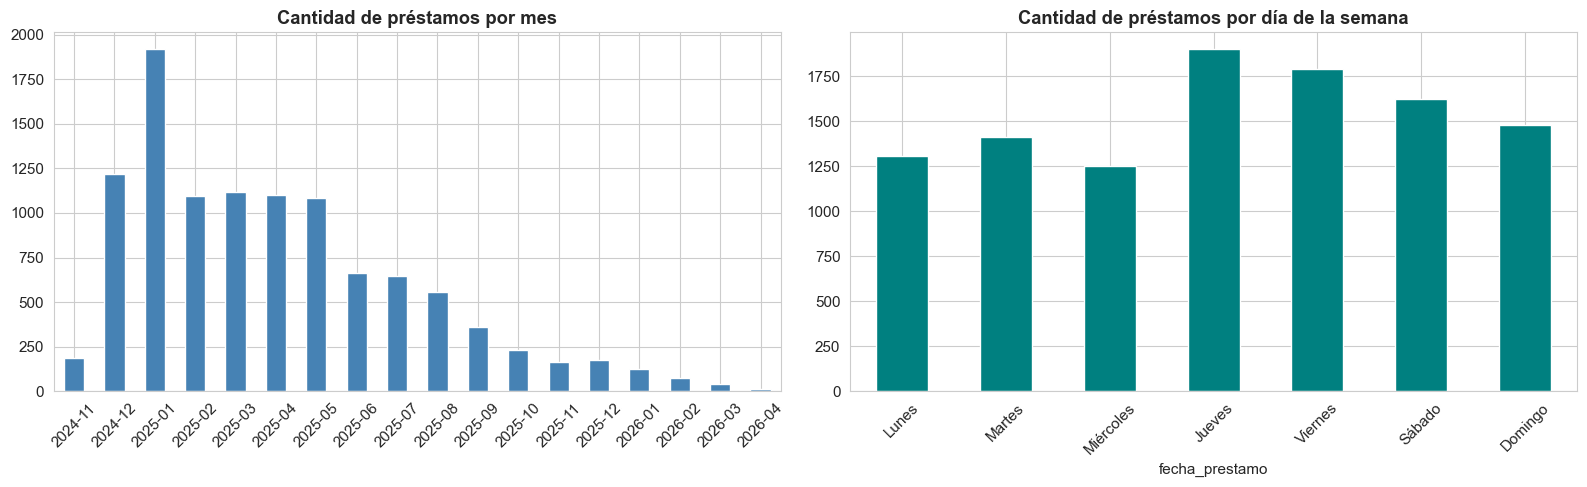

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por mes
ax = axes[0]
df["fecha_prestamo"].dt.to_period("M").value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Cantidad de prestamos por mes", fontweight="bold")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)

# Por dÃ­a de la semana
ax = axes[1]
dias = ["Lunes", "Martes", "MiÃ©rcoles", "Jueves", "Viernes", "SÃ¡bado", "Domingo"]
df["fecha_prestamo"].dt.dayofweek.value_counts().sort_index().plot(kind="bar", ax=ax, color="teal")
ax.set_xticklabels(dias, rotation=45)
ax.set_title("Cantidad de prestamos por dí­a de la semana", fontweight="bold")

plt.tight_layout()
plt.show()

---
## 4. Análisis Bivariable

Se analiza la relaciÃ³n de cada variable con la variable objetivo `Pago_atiempo`.

### 4.1 Variables numéricas vs Pago_atiempo

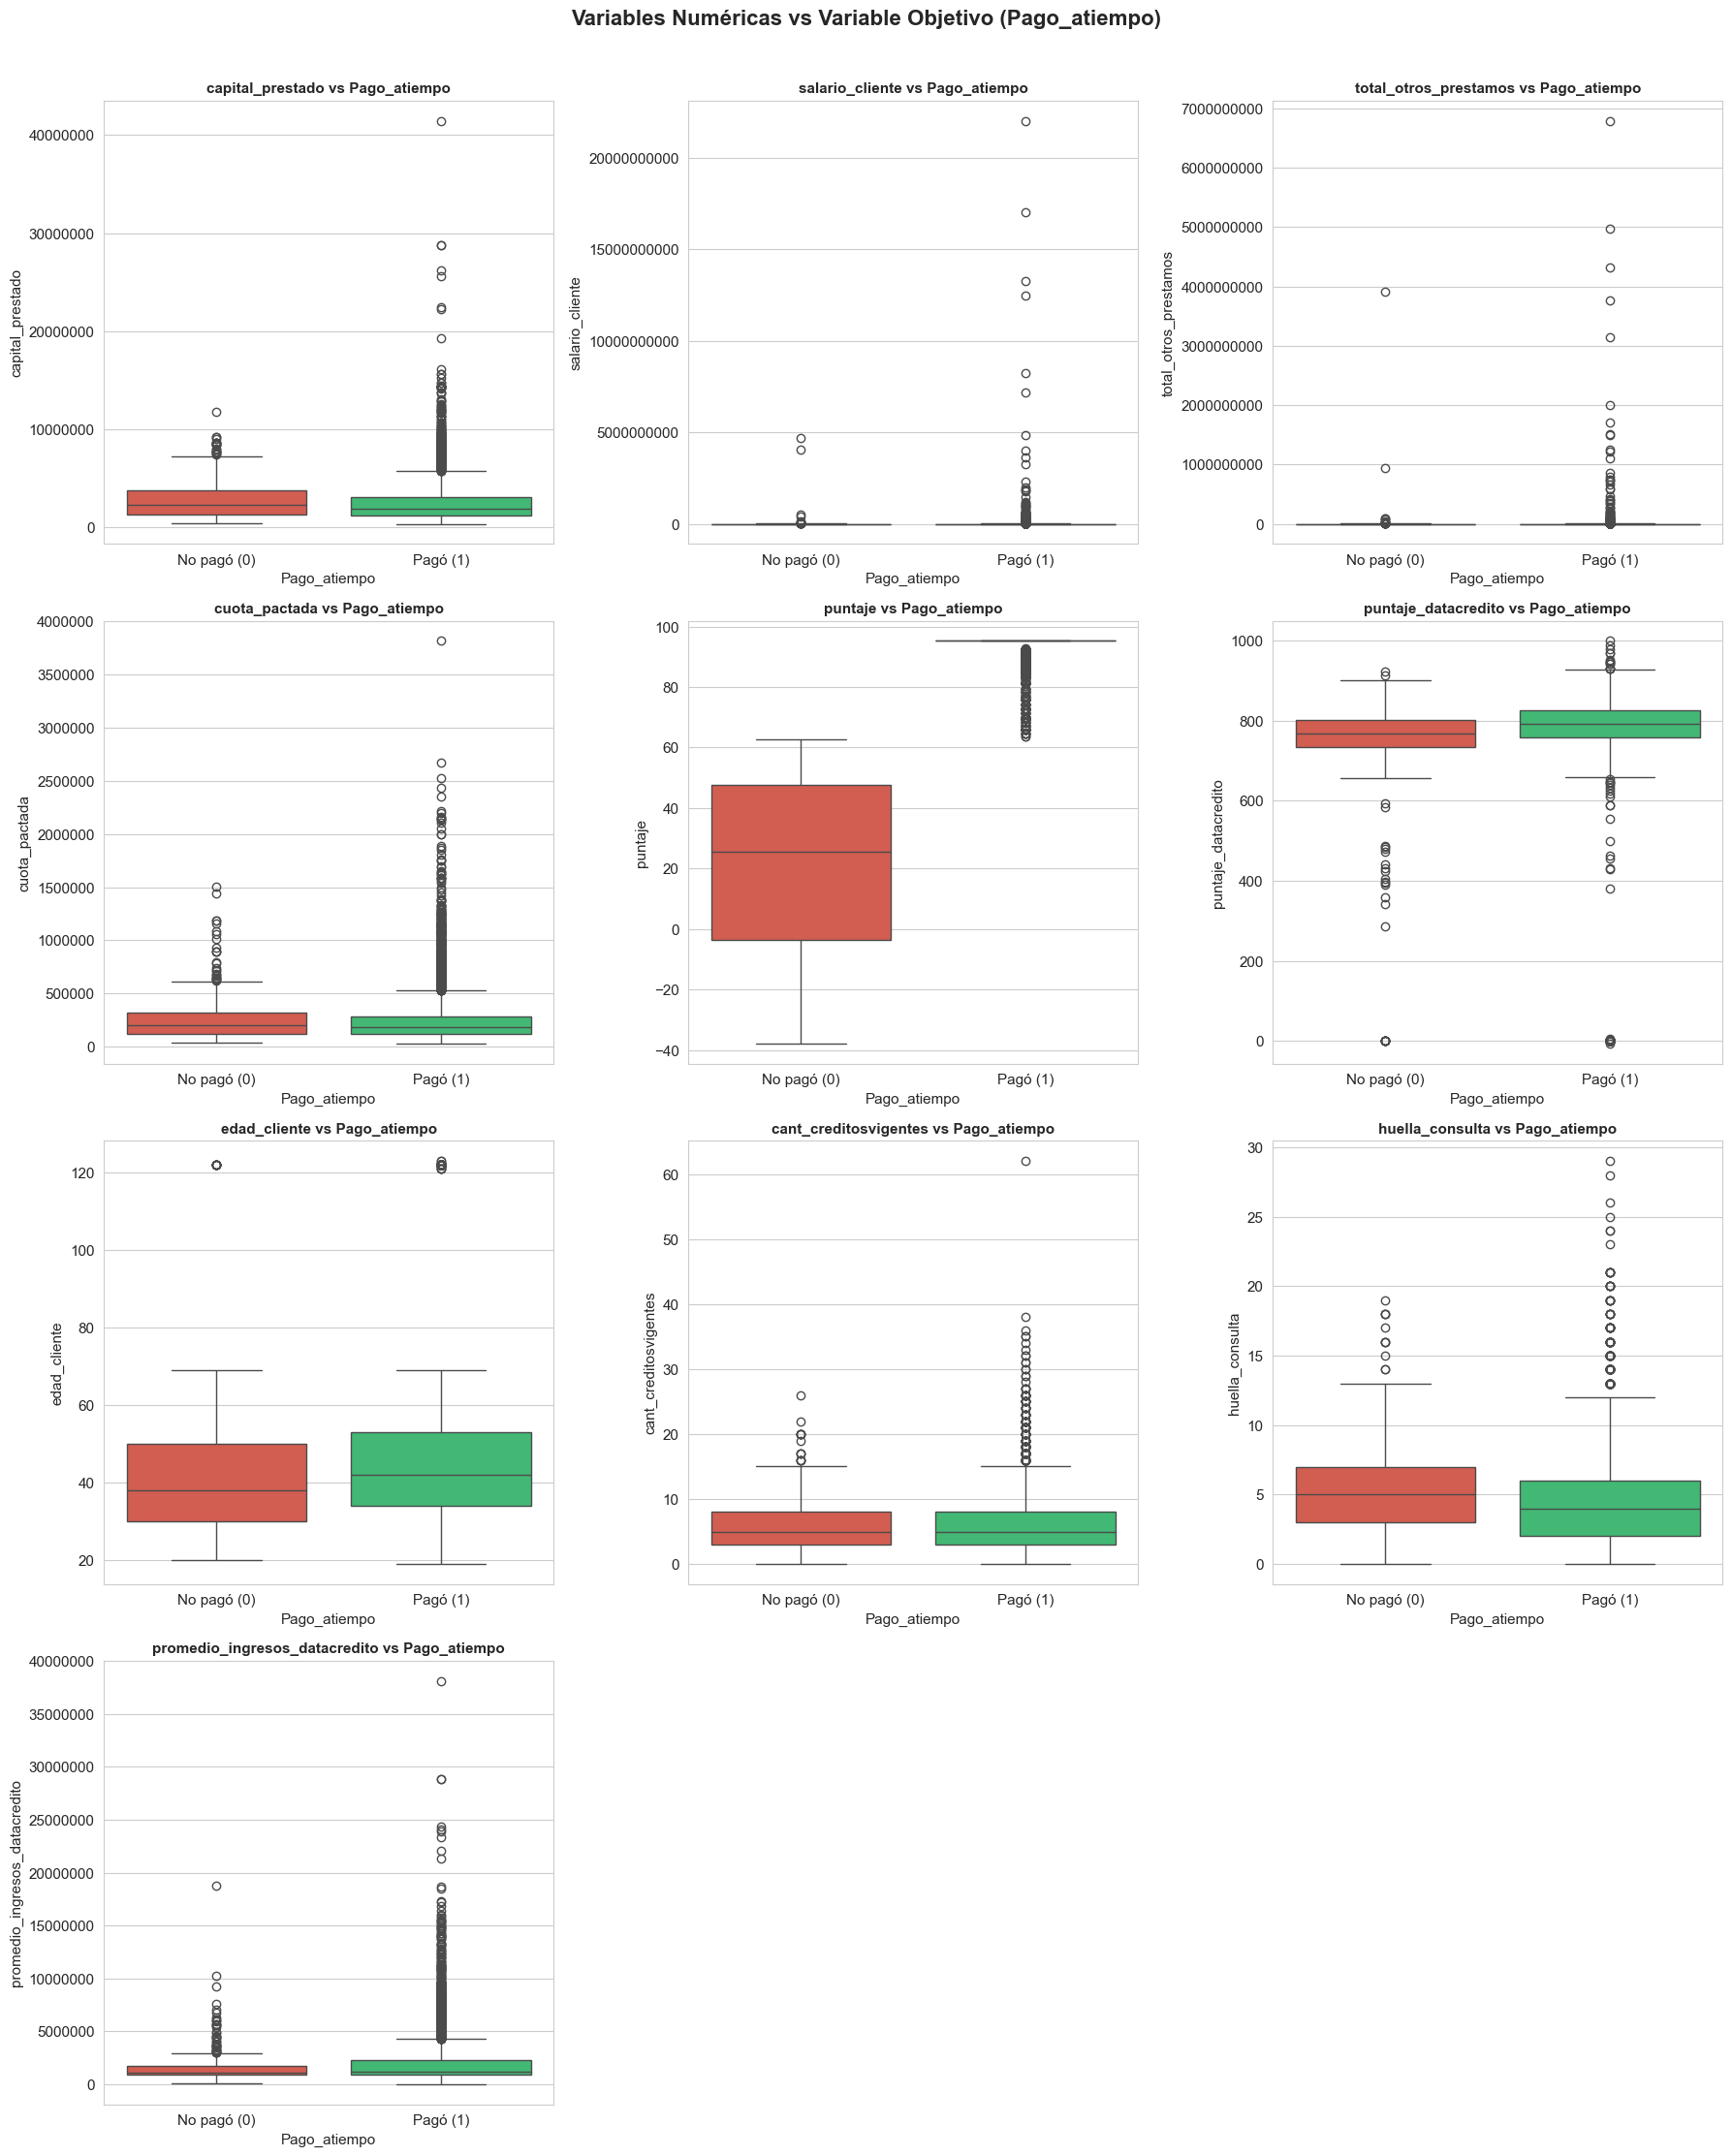

In [37]:
cols_num_biv = ["capital_prestado", "salario_cliente", "total_otros_prestamos",
                "cuota_pactada", "puntaje", "puntaje_datacredito",
                "edad_cliente", "cant_creditosvigentes", "huella_consulta",
                "promedio_ingresos_datacredito"]

fig, axes = plt.subplots(4, 3, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(cols_num_biv):
    ax = axes[i]
    sns.boxplot(data=df, x="Pago_atiempo", y=col, ax=ax,
               palette={0: "#e74c3c", 1: "#2ecc71"}, hue="Pago_atiempo", legend=False)
    ax.set_title(f"{col} vs Pago_atiempo", fontsize=11, fontweight="bold")
    ax.set_xticklabels(["No pagÃ³ (0)", "PagÃ³ (1)"])
    ax.ticklabel_format(style="plain", axis="y")

for j in range(len(cols_num_biv), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Variables NumÃ©ricas vs Variable Objetivo (Pago_atiempo)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Interpretación del anÃ¡lisis bivariable (numÃ©ricas vs objetivo):**
- **puntaje:** Es probablemente la variable mÃ¡s discriminante. Los clientes que pagan a tiempo tienen puntajes significativamente mÃ¡s altos.
- **puntaje_datacredito:** Similar al puntaje interno, valores mÃ¡s altos se asocian con pagos a tiempo.
- **capital_prestado:** Los montos mÃ¡s altos pueden estar asociados con mayor riesgo de impago.
- **salario_cliente:** Clientes con salarios mÃ¡s altos tienden a pagar mÃ¡s a tiempo.
- **saldo_mora:** Clientes con saldos en mora mÃ¡s altos tienen mayor probabilidad de no pagar a tiempo.
- **edad_cliente:** No parece haber una diferencia muy marcada, pero se debe validar estadÃ­sticamente.

### 4.2 Variables categóricas vs Pago_atiempo

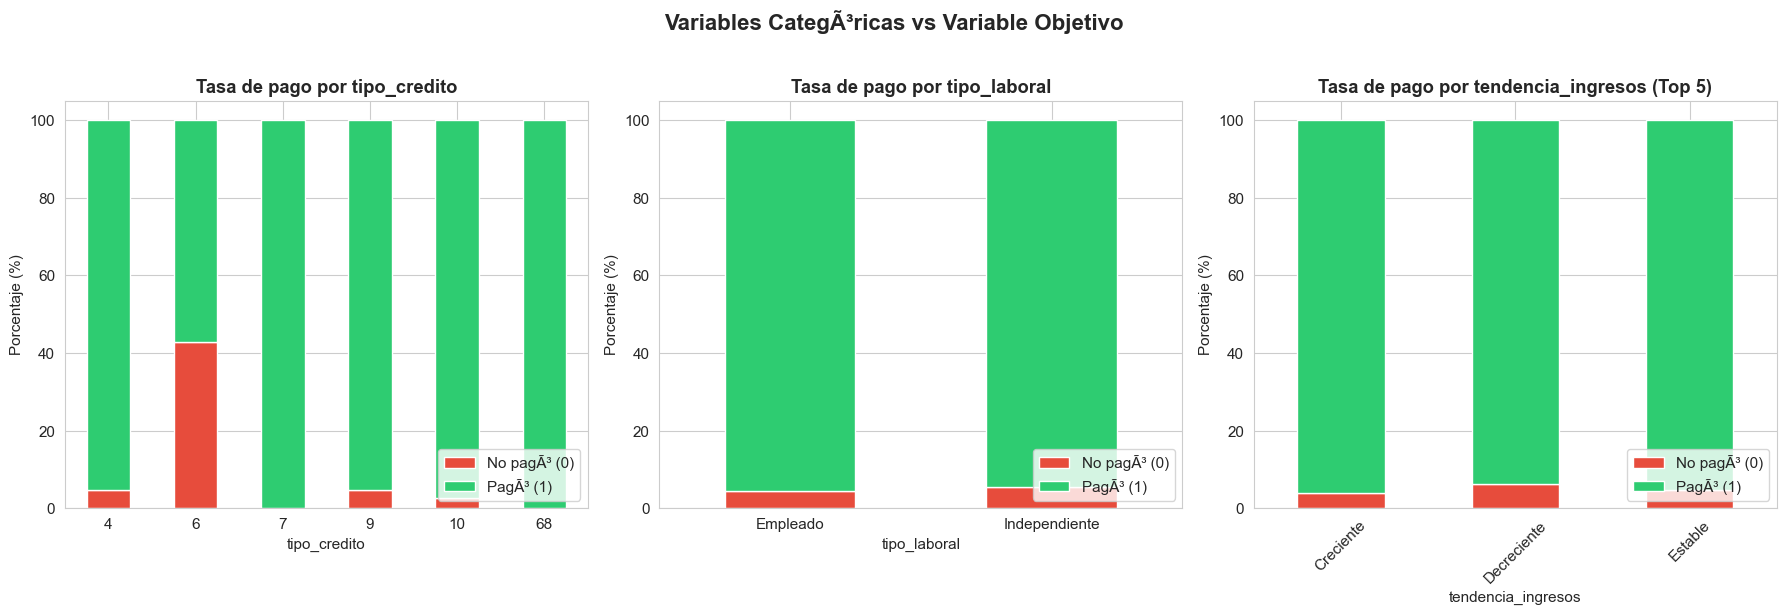

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# tipo_credito vs Pago_atiempo
ax = axes[0]
ct1 = pd.crosstab(df["tipo_credito"], df["Pago_atiempo"], normalize="index").mul(100)
ct1.plot(kind="bar", stacked=True, ax=ax, color=["#e74c3c", "#2ecc71"], edgecolor="white")
ax.set_title("Tasa de pago por tipo_credito", fontweight="bold")
ax.set_ylabel("Porcentaje (%)")
ax.legend(["No pagÃ³ (0)", "PagÃ³ (1)"], loc="lower right")
ax.tick_params(axis="x", rotation=0)

# tipo_laboral vs Pago_atiempo
ax = axes[1]
ct2 = pd.crosstab(df["tipo_laboral"], df["Pago_atiempo"], normalize="index").mul(100)
ct2.plot(kind="bar", stacked=True, ax=ax, color=["#e74c3c", "#2ecc71"], edgecolor="white")
ax.set_title("Tasa de pago por tipo_laboral", fontweight="bold")
ax.set_ylabel("Porcentaje (%)")
ax.legend(["No pagÃ³ (0)", "PagÃ³ (1)"], loc="lower right")
ax.tick_params(axis="x", rotation=0)
# tendencia_ingresos vs Pago_atiempo (solo top 10 categorÃ­as)
ax = axes[2]

top = df["tendencia_ingresos"].value_counts().head(10).index
df_temp = df[df["tendencia_ingresos"].isin(top)]

ct3 = pd.crosstab(df_temp["tendencia_ingresos"], df_temp["Pago_atiempo"], normalize="index").mul(100)

ct3.plot(kind="bar", stacked=True, ax=ax, color=["#e74c3c", "#2ecc71"], edgecolor="white")

ax.set_title("Tasa de pago por tendencia_ingresos (Top 5)", fontweight="bold")
ax.set_ylabel("Porcentaje (%)")
ax.legend(["No pagÃ³ (0)", "PagÃ³ (1)"], loc="lower right")
ax.tick_params(axis="x", rotation=45)

plt.suptitle("Variables CategÃ³ricas vs Variable Objetivo", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Interpretación del anÃ¡lisis bivariable (categóricas vs objetivo):**
- **tipo_credito:** Diferentes tipos de crÃ©dito muestran tasas de pago a tiempo distintas. Algunos tipos son mÃ¡s riesgosos que otros.
- **tipo_laboral:** Analizar si los empleados o independientes tienen mejor tasa de pago.
- **tendencia_ingresos:** Los clientes con tendencia "Creciente" pueden tener mejor comportamiento de pago. Los nulos son interesantes: podrÃ­an representar un grupo con caracterÃ­sticas particulares de riesgo.

### 4.3 Variables de saldo vs Pago_atiempo

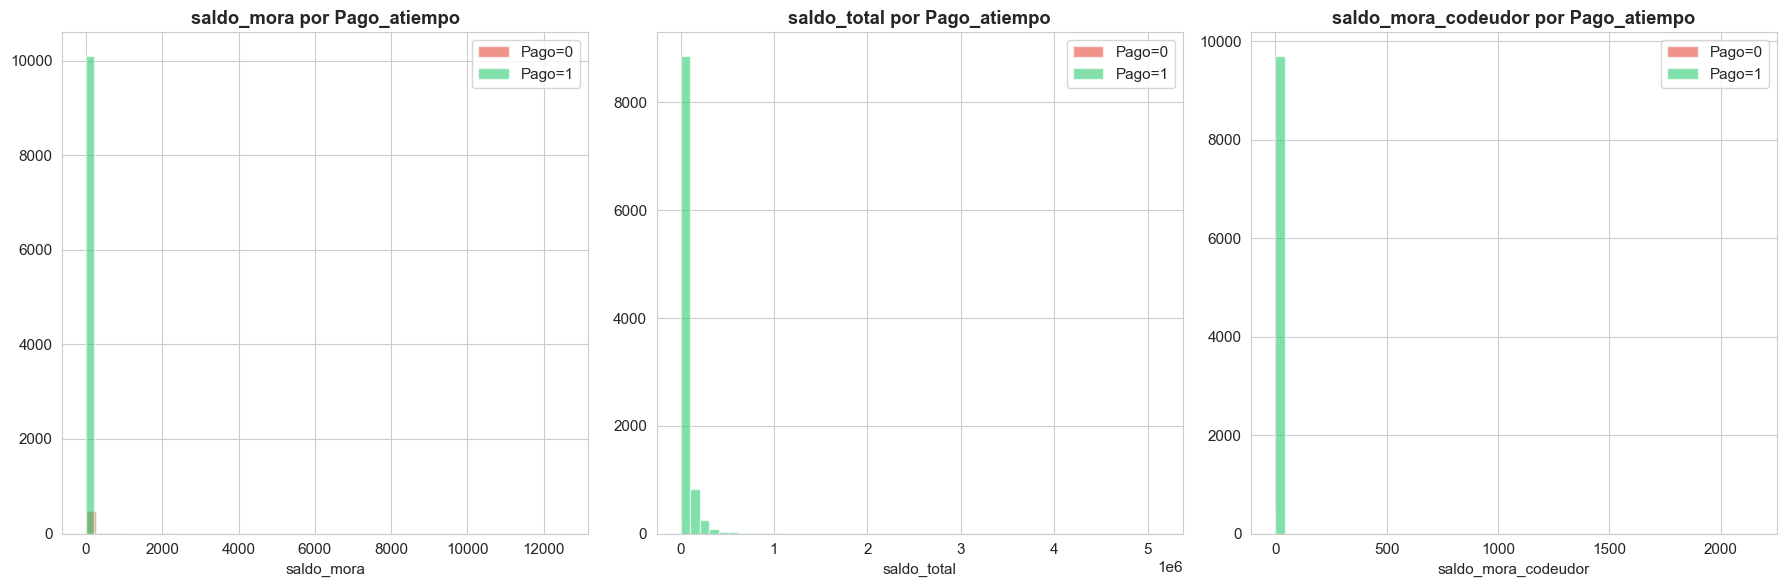

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (col, ax) in enumerate(zip(["saldo_mora", "saldo_total", "saldo_mora_codeudor"], axes)):
    for label, color in zip([0, 1], ["#e74c3c", "#2ecc71"]):
        data = df[df["Pago_atiempo"] == label][col].dropna()
        ax.hist(data, bins=50, alpha=0.6, color=color, label=f"Pago={label}", edgecolor="white")
    ax.set_title(f"{col} por Pago_atiempo", fontweight="bold")
    ax.legend()
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

---
## 5. Análisis Multivariable

### 5.1 Matriz de correlaciÃ³n

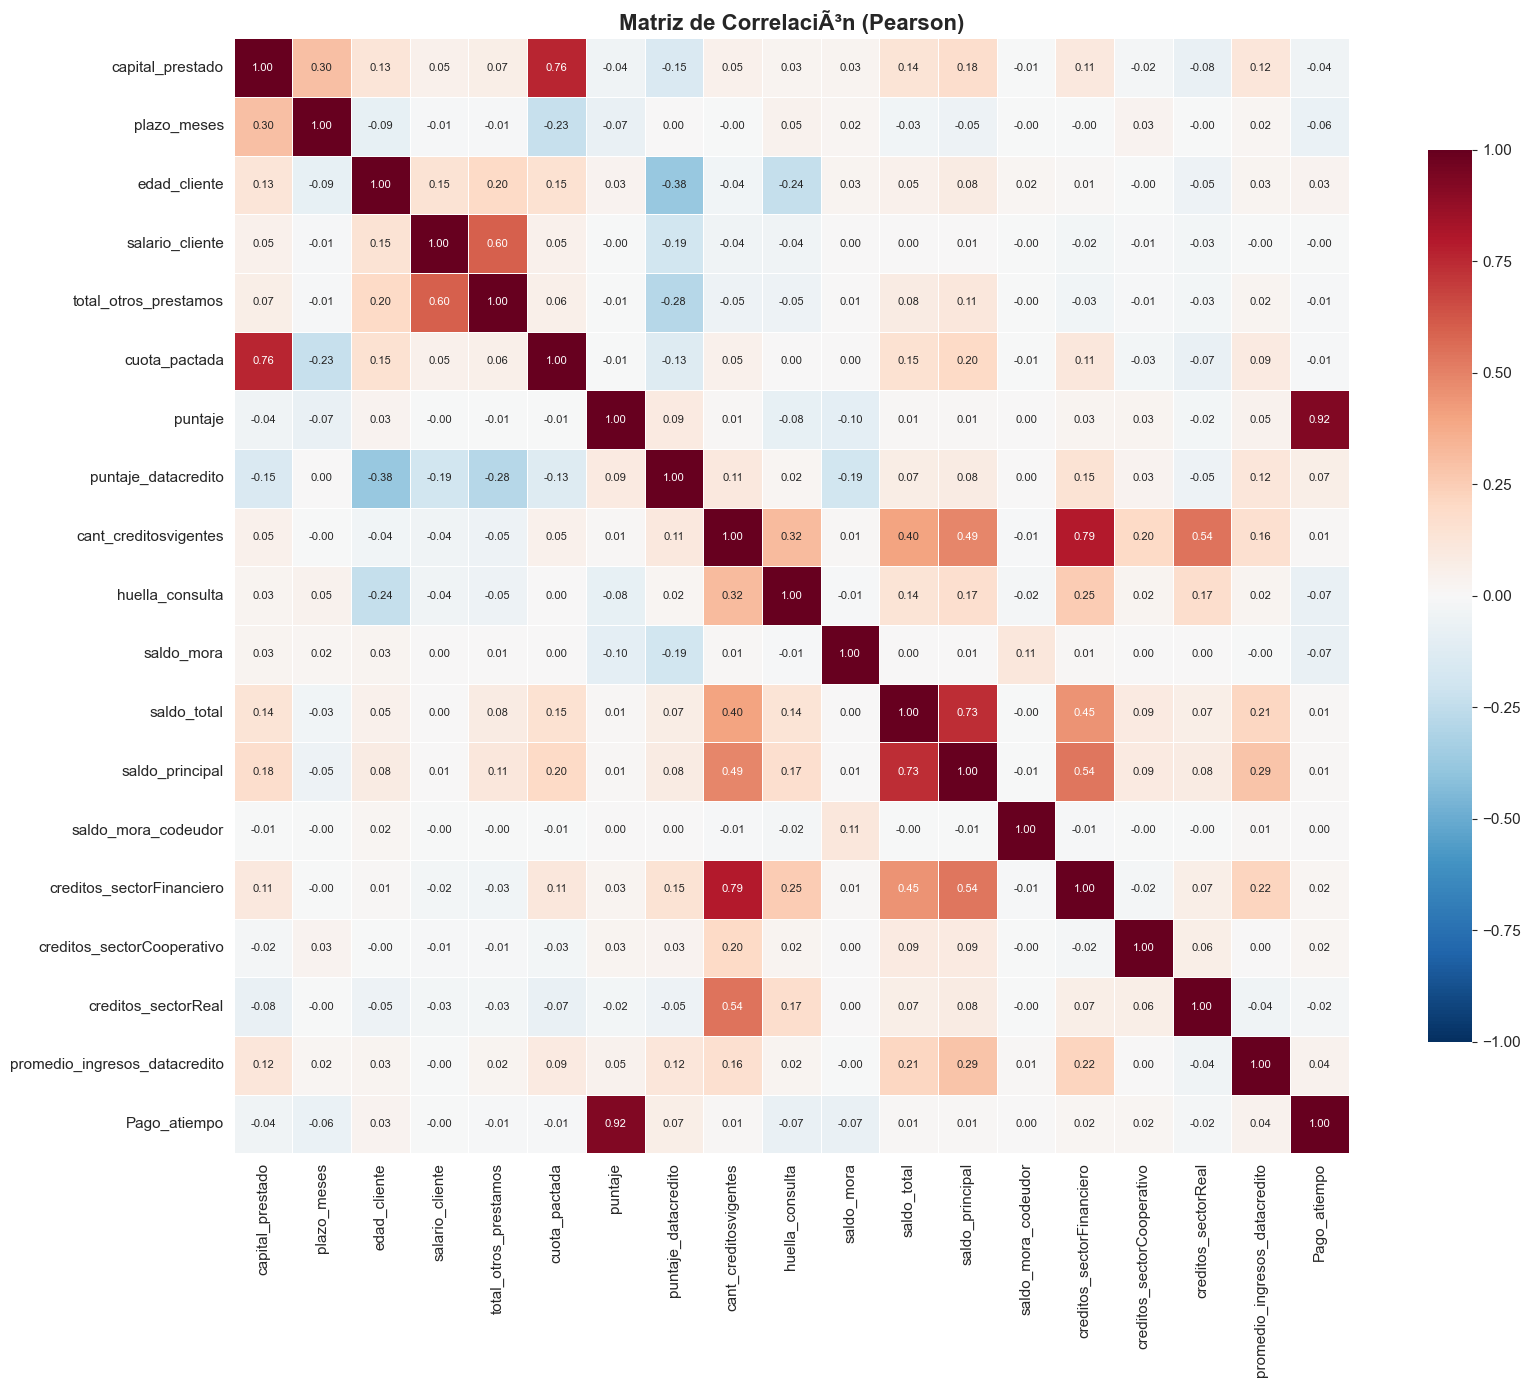

In [ ]:
# NOTA: saldo_mora, saldo_total, saldo_principal y saldo_mora_codeudor
# presentan data leakage (son consecuencia del target, no predictoras).
# Se incluyen aquí solo para fines exploratorios del EDA.

cols_corr = ["capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
             "total_otros_prestamos", "cuota_pactada", "puntaje", "puntaje_datacredito",
             "cant_creditosvigentes", "huella_consulta", "saldo_mora", "saldo_total",
             "saldo_principal", "saldo_mora_codeudor", "creditos_sectorFinanciero",
             "creditos_sectorCooperativo", "creditos_sectorReal",
             "promedio_ingresos_datacredito", "Pago_atiempo"]

corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={"size": 8})
ax.set_title("Matriz de Correlación", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Correlaciones con Pago_atiempo (ordenadas por magnitud):
puntaje                          0.92
huella_consulta                 -0.07
saldo_mora                      -0.07
puntaje_datacredito              0.07
plazo_meses                     -0.06
capital_prestado                -0.04
promedio_ingresos_datacredito    0.04
edad_cliente                     0.03
creditos_sectorReal             -0.02
creditos_sectorFinanciero        0.02
creditos_sectorCooperativo       0.02
saldo_total                      0.01
cuota_pactada                   -0.01
saldo_principal                  0.01
total_otros_prestamos           -0.01
cant_creditosvigentes            0.01
salario_cliente                 -0.00
saldo_mora_codeudor              0.00


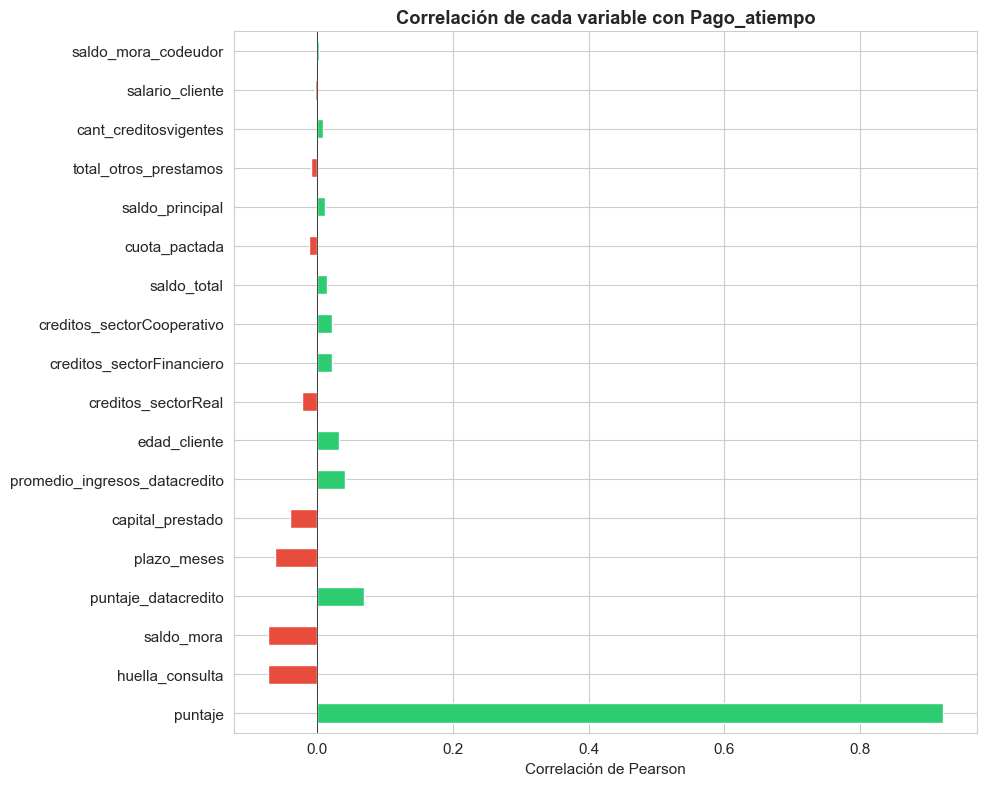

In [48]:
# Correlaciones mÃ¡s fuertes con la variable objetivo
corr_target = corr_matrix["Pago_atiempo"].drop("Pago_atiempo").sort_values(key=abs, ascending=False)
print("Correlaciones con Pago_atiempo (ordenadas por magnitud):")
print(corr_target.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in corr_target]
corr_target.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Correlación de cada variable con Pago_atiempo", fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Correlación de Pearson")
plt.tight_layout()
plt.show()

## 8. Conclusiones del EDA

### Hallazgos principales

El análisis exploratorio de datos permitió identificar aspectos clave del dataset y su potencial para la construcción de un modelo predictivo de comportamiento de pago.

En términos de **calidad de datos**, el conjunto presenta buena consistencia general. Los valores nulos se concentran principalmente en variables como `promedio_ingresos_datacredito` y `tendencia_ingresos`, así como en algunas variables relacionadas con saldos. No se evidencian problemas estructurales relevantes.

La variable objetivo `Pago_atiempo` es de tipo binaria, lo que configura un problema de clasificación. Se recomienda evaluar el nivel de desbalance de clases antes de entrenar modelos.

En cuanto a la **relevancia de las variables**, se identificó que:


- Variables como `plazo_meses`, `capital_prestado` y `huella_consulta` presentan relaciones con el target, lo que sugiere que capturan aspectos relevantes del riesgo crediticio.
- Otras variables, como los conteos de créditos por sector y características demográficas, presentan menor correlación individual, pero pueden aportar valor en modelos más complejos.

Es importante destacar que las variables relacionadas con saldos (`saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor`, `puntaje` ) presentan **data leakage**, ya que reflejan el estado del crédito posterior a su otorgamiento. Por lo tanto, deben excluirse del proceso de modelado predictivo.

En conclusión, el dataset cuenta con variables relevantes y adecuadas para la construcción de un modelo de riesgo crediticio, siempre que se realice una correcta selección de variables, manejo de datos faltantes y prevención de fuga de información.



